# 과제 4 : 문서 분류(Naive Bayes) & 감성 분석

**선택한 사이트 : 올리브영** (https://www.oliveyoung.co.kr/)

**과제 내용**

1. **Naïve Bayes Classifier** — 카테고리 3개 × 상품명 10개씩 수집·전처리 후 NBC 문서 분류기 학습
2. **Sentiment Analysis** — 상품 하나를 골라 ★5 리뷰 10개 / ★1 리뷰 10개 수집·전처리 후 긍/부정 분류
   - 수집한 텍스트의 길이는 어땠는가? **분류별 텍스트 길이가 분석 결과에 어떤 영향을 미치는가?**

---
## 0. 환경 설정

In [ ]:
%pip install -q konlpy scikit-learn

In [1]:
import re
import time
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

In [3]:
# 한글 폰트 & 색상
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_font():
    '''설치된 한글 폰트를 자동으로 찾아 적용한다.'''
    candidates = [
        'Malgun Gothic',       # Windows
        'AppleGothic',         # macOS
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            break
    else:
        print('[경고] 한글 폰트를 찾지 못했습니다. 라벨이 □로 보일 수 있습니다.')
    plt.rcParams.update({
        'axes.unicode_minus': False,   # 음수 부호 깨짐 방지
    })

setup_font()

BLUE, ORANGE = "#4269D0", "#C26A1E"
INK, MUTED = "#1F2328", "#6B7280"

### 0.1 예시 데이터

In [4]:
PRODUCTS = {
    "스킨케어": [
        "[9월 올영픽/산리오캐릭터즈 콜라보] 아누아 피디알엔 히알루론산 캡슐 100 세럼 30ml 더블기획(+시나모롤 파우치)",
        "[1등크림] 에스트라 아토베리어365 크림 80ml 기획(+토너25ml+클렌징폼3g*3EA)",
        "쥬베룩 PDLLA 콜라겐 부스팅 앰플 20g (+프로텍팅 크림 2ml*5EA) (2604)",
        "[9월올영픽/리뷰이벤트/헬로키티] 에스네이처 아쿠아 오아시스 수분 젤크림 90ml 기획 (+헬로키티 러기지택)",
        "[9월 올영픽/산리오캐릭터즈] 온그리디언츠 바쿠글로우 캡슐 로션 150ml 기획 (+30ml+시나모롤 장바구니)",
        "[9월 올영픽/손상장벽집중케어]라로슈포제 시카플라스트밤 B5+ 100ml 기획 (+시카에센스7.5ml+히알루세럼3ml)",
        "[9월올영픽/리뷰이벤트/헬로키티] 에스네이처 아쿠아 스쿠알란 수분크림 60ml 더블기획 (+헬로키티 키캡키링)",
        "[9월 올영픽] 토리든 다이브인 저분자 히알루론산 세럼 50ml 리필 기획 (+50ml 리필+자석인형) (시나모롤)",
        "[26년 신형/보습광채] 달바 퍼스트 스프레이 세럼 펩타이드 100ml 더블기획",
        "[각질쓱싹/대용량] 디오디너리 글리코릭 애시드 7% 엑스폴리에이팅 토너 240ml",
    ],
    "마스크팩": [
        "[15년 연속 1위] 메디힐 에센셜 마스크팩 10/10+1매 기획 7종 골라담기",
        "[산리오캐릭터즈 에디션] 메디힐 더마 토너패드 100+100매 7종 골라담기",
        "[7+1/산리오 굿즈 증정] 바이오던스 리얼 딥 마스크 7+1매 기획(콜라겐/세라놀)(+헬로키티/포차코 마우스패드)",
        "[15년연속 1위] 메디힐 에센셜 마스크팩 1매 고기능 7종 골라담기",
        "[1+1/한정기획] 스킨푸드 캐롯 카로틴 카밍 워터 패드 60매 더블기획 (+PDRN 패드 2매*3)",
        "[수지pick/단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 or +2매 추가 증정)",
        "[8+1매 단독기획] 메디힐 하이퍼 겔마스크 4종 (콜라겐/PDRN/마데카소사이드/히알루론산)",
        "[1등모공패드/대용량160매] 메디큐브 패드 3종 1+1 140매 리필 기획 (제로모공패드/PDRN겔패드/딥비타씨패드)",
        "[산리오캐릭터]토리든 다이브인 저분자 히알루론산 마스크 10매 기획 (+시나모롤 캐릭터 마스크 1매 증정)",
        "[9월 올영픽/산리오] 아비브 어성초 흔적 에센스 패드 클리어터치 70매 기획 (+70매 리필+패드케이스+스티커)",
    ],
    "선케어": [
        "[미니어처 단독기획/양현종 PICK] 메디힐 마데카소사이드 수분 선세럼 흔적 리페어 50+50+15g 기획",
        "[1+1/파데프리톤업선] 이니스프리 데일리 유브이 톤업 노세범 선크림 50ml 더블 기획",
        "[1+1]토코보 선스틱 SPF50+ PA++++ (코튼/비타/쿨링)",
        "[1+1/1등썬] 라운드랩 자작나무 수분 선크림 50ml 1+1 기획 (+수분 선세럼 8ml)",
        "[레올영PICK] AHC 마스터즈 아쿠아리치 선크림 50ml 1+1 기획",
        "[파데프리/톤업선크림]체이싱래빗 올어바웃글로우 커버크림 35g기획(단품/ 대왕퍼프)",
        "[1위선세럼/미니증정] 스킨1004 마다가스카르 센텔라 히알루-시카 워터핏 선세럼 기획(50ml+50ml+15ml)",
        "[50%용량증정] 에스트라 더마UV365 장벽수분 무기자차 선크림 40ml+20ml",
        "[쿨톤보정] 달바 퍼플 톤업 선크림 듀오 기획 (50ml+50ml)",
        "[산리오 콜라보] 구달 맑은 어성초 진정 수분 선크림 50+50ml 기획 (+시나모롤 카드스티커)",
    ],
}

print("카테고리별 상품 수 :", {k: len(v) for k, v in PRODUCTS.items()})
for cat, names in PRODUCTS.items():
    print(f"\n[{cat}]")
    for n in names[:3]:
        print("  -", n)
    print("  ...")

카테고리별 상품 수 : {'스킨케어': 10, '마스크팩': 10, '선케어': 10}

[스킨케어]
  - [9월 올영픽/산리오캐릭터즈 콜라보] 아누아 피디알엔 히알루론산 캡슐 100 세럼 30ml 더블기획(+시나모롤 파우치)
  - [1등크림] 에스트라 아토베리어365 크림 80ml 기획(+토너25ml+클렌징폼3g*3EA)
  - 쥬베룩 PDLLA 콜라겐 부스팅 앰플 20g (+프로텍팅 크림 2ml*5EA) (2604)
  ...

[마스크팩]
  - [15년 연속 1위] 메디힐 에센셜 마스크팩 10/10+1매 기획 7종 골라담기
  - [산리오캐릭터즈 에디션] 메디힐 더마 토너패드 100+100매 7종 골라담기
  - [7+1/산리오 굿즈 증정] 바이오던스 리얼 딥 마스크 7+1매 기획(콜라겐/세라놀)(+헬로키티/포차코 마우스패드)
  ...

[선케어]
  - [미니어처 단독기획/양현종 PICK] 메디힐 마데카소사이드 수분 선세럼 흔적 리페어 50+50+15g 기획
  - [1+1/파데프리톤업선] 이니스프리 데일리 유브이 톤업 노세범 선크림 50ml 더블 기획
  - [1+1]토코보 선스틱 SPF50+ PA++++ (코튼/비타/쿨링)
  ...


In [5]:
TARGET_PRODUCT = "[산리오캐릭터즈 에디션] 메디힐 더마 토너패드 100+100매 7종 골라담기"

REVIEWS_5 = [
    "안에 앰플 양도 많고 닦아서 쓰기도 좋고 팩으로도 쓰기 좋아요",
    "그냥 누구에게나 좋음 토너패드 고민된다 하면 당근이나 이거 괜춘",
    "산리오 캐릭터 패키지가 너무 귀여워서 구매한 토너 패드입니다. 패드 두께가 적당하고 표면 거친 면과 부드러운 면이 나뉘어 있어 활용도가 높습니다. 거친 면으로 각질을 정리하고 부드러운 면으로 피부를 진정시켜줄 수 있습니다. 토너 액이 충분히 담겨있지만 흘러내리지 않고 피부에 사용했을 때 자극이 적습니다. 세안 후 피부결 정돈, 화장 전 준비 단계로 사용하기 좋고 민감한 피부도 부담 없이 쓸 수 있습니다. 100+100매 넉넉한 구성에 굿즈까지 증정되어 만족도가 높습니다. 매일 간편하게 피부 관리하고 싶으신 분께 추천합니다。",
    """양 많아서 좋아요
세수하고 바로 붙여주고 있어요 흔적 케어는 아직 잘 모르겠음""",
    "티트리 성분이라 트러블 부위에 붙였을 때 진정되는 느낌이 확실히 들어요. 토너가 충분히 적셔져 있어서 패드만으로도 촉촉함이 유지되고, 얼굴에 밀착이 잘 돼서 사용감도 편했습니다. 자극 없이 순하게 진정시켜주는 느낌이라 트러블 난 날에도 부담 없이 사용할 수 있었어요. 100매나 들어있어서 넉넉하게 매일 사용해도 오래 쓸 수 있는 점도 만족스러웠습니다. 사용 후 피부가 한결 편안해지고 붉은기도 줄어드는 느낌이라 재구매 의사 있는 제품이었어요.",
    "최고의 콜라보 😍😍!! 믿고 쓰는 제품과 좋아하는 캐릭터가 만나니 환상이네요😍",
    "제가 써보고 너무 만족한 제품이라서 친구 생일선물로 주려고 구매했습니다! 양도 많고 에센스도 넉넉해서 마지막까지 촉촉하게 쓸 수 있어요 재질은 거즈지만 팩토하기에 딱입니당 세럼보다 여드름 흔적 개선에 효과를 더 많이 봤습니다!! 그리고 픽커? 팩 들어올리는 도구도 깔끔하게 팩을 잡을 수 있어서 너무 유용합니다 재구매 의사 200%!!",
    "산리오 스티커 귀엽습니다~! 재재구매템이예요 피부결 정돈, 진정에 좋아요",
    "닦토용으로도 괜찮고 빠르게 간단하게 토너팩용으로도 두루두루 좋네요",
    "토너패드 중에 젤 무난하게 여러 방면으로 사용하기 좋은거 같아요 !",
]

REVIEWS_1 = [
    """평소에 메디힐 마스크팩을 쓰고 진정효과를 봐서 이번에 토너패드도 이걸로 바꿔봤는데.... 피부 뒤집어졌습니다.....
원래 피부가 예민해서 닦토는 안하고 아침에 팩토만 했는데... 넘 속상해요.. 당시에는 촉촉하고 끈적임 없어서 좋았는데 뒤집어져버려서... 못쓰겠네요""",
    "제품은 좋은데 휴대용 케이스는 의미가 없네요 질질 새서 ...",
    "배송잘못은 회사가 해놓고 환불신청도안했는데 다시환불이라니요? 어의없네요 다시배송해주시면되는건데 그것두 고객한테 물어봐야하는것아닌가요? 무슨 경우없는 일인가요 ㅠㅠ",
    "배송완료라고 문자하시더니 몇분후 바로 환불한다는 문자가오고 뭐하시는건지 ㅠㅠ 하루반에 배송이 안되면 다른날로 배송해도 되냐고 물어본다음에 환불해줘야하는거 아닌가요? 하루지나니까 할인금액으로 구매를못하네요 ㅠㅠ",
    "당근패드 사용하다 세일해서 구매해봄 결과는 당근이 훨신 좋움",
    """패드가 리뉴얼 되었네요...
닦토용으로 산건데 너무 흐물텅 거려서 안 좋아요
전에 사용한적 있어서 두개 주문했는데ㅠㅠ
다음엔 다른거 살래요...""",
    """이 상품의 구매자분들은 주의하시기 바랍니다!!!!!!
마치 이 물건을 구매하면 사은품을 모두 줄 것 같은 어그로용 상품사진에 깜빡 속아서 구매를 했는데, 옵션을 상세히 꼼꼼이 하나하나 살펴보고 특정 상품을 구매해야만 사은품을 주도록 옵션 설정되어 있습니다. 아마 저처럼 문의하는 사람들이 많았는지 지금은 옵션설정에 사진을 올려놨지만, 며칠전에는 사진없이 텍스트옵션만 있었습니다. 저처럼 꼼꼼한 소비자도 깜빡 속을 수밖에 없게끔요. 소비자 입장에서 봤을 때, 소비자를 기만하는 홍보방식이라고 여겨집니다. 이런 비열한 홍보방식은 앞으로 지양하시지 바랍니다.""",
    "패드가 피부에 자극되는지 쓰고 접촉성 피부염때문에 고생함 피부예민하면 이런패드형은 쓰지마시길",
    "분명 휴대용케이스와 스티커가 있다고 했는데, 본품과 리필만 있고 휴대용케이스가 없네요",
    "아니 왜 패드 리뉴얼 하셨나요ㅠ 전이 훨씬 좋은데 원래 쭉 늘려서 쓰는 게 포인트 아니었어요? 별로입니다. 다시 돌려줘요ㅠ 팩토용으로 쓰는데 이건 붙이고 있으니까 간지럽기까지 합니다.. 하... 성분 자체는 좋아요! 좋은데 패드 이대로면 두번 다시 안 살 듯 이번에 산 것도 안 쓸 것 같은데 돈 아까워요",
]

print("감성분석 대상 :", TARGET_PRODUCT)
print(f"★5 리뷰 {len(REVIEWS_5)}개 / ★1 리뷰 {len(REVIEWS_1)}개")
print("\n[★5 예시]", REVIEWS_5[0])
print("\n[★1 예시]", REVIEWS_1[0][:60], "...")

감성분석 대상 : [산리오캐릭터즈 에디션] 메디힐 더마 토너패드 100+100매 7종 골라담기
★5 리뷰 10개 / ★1 리뷰 10개

[★5 예시] 안에 앰플 양도 많고 닦아서 쓰기도 좋고 팩으로도 쓰기 좋아요

[★1 예시] 평소에 메디힐 마스크팩을 쓰고 진정효과를 봐서 이번에 토너패드도 이걸로 바꿔봤는데.... 피부 뒤집어졌습니다 ...


### 0.2 전처리

**중요 : 상품명과 리뷰는 전처리 방식이 달라야 한다.**

| | 상품명 | 리뷰 |
|---|---|---|
| 남길 품사 | 명사 · 영문 · 숫자 (`SPF50`, `500ml` 도 특징이 된다) | 명사 + **용언(동사·형용사)** + 부사 |
| 불용어 | 거의 없음 (단어 자체가 적음) | 일반 불용어는 제거 |
| **절대 지우면 안 되는 것** | — | **`좋다`, `없다`, `않다`, `안`, `못`** — 감성의 핵심 신호 |

In [6]:
from konlpy.tag import Komoran

USER_DIC = """\\
선크림\tNNG
선스틱\tNNG
선세럼\tNNG
선쿠션\tNNG
선젤\tNNG
선로션\tNNG
선밤\tNNG
선스크린\tNNG
선프라이머\tNNG
클렌징폼\tNNG
클렌징\tNNG
토너\tNNG
세럼\tNNG
앰플\tNNG
크림\tNNG
로션\tNNG
무기자차\tNNG
좁쌀\tNNG
"""
with open("user_dic.txt", "w", encoding="utf-8") as f:
    f.write(USER_DIC)

komoran = Komoran(userdic="./user_dic.txt")
print(komoran.pos("톤업 선크림 SPF50+ 50ml"))

[('톤', 'NNG'), ('업', 'NNG'), ('선크림', 'NNG'), ('SPF', 'SL'), ('50', 'SN'), ('+', 'SW'), ('50', 'SN'), ('ml', 'SL')]


In [7]:
def clean_text(text):
    text = re.sub(r"[^가-힣A-Za-z0-9\s\+\.]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def prep_product(text):
    """상품명용 : 명사·영문·숫자를 모두 남긴다 (용량/SPF 도 카테고리 단서가 된다)"""
    out = []
    for w, p in komoran.pos(clean_text(text)):
        if p in ("NNG", "NNP", "SL", "SN", "SH"):
            out.append(w.upper() if p == "SL" else w)
    return out


# 리뷰용 불용어 : 감성어(좋다/없다/않다 등)는 절대 넣지 않는다
REV_STOP = set("""
것 수 등 저 제 때 점 거 게 좀 정말 진짜 그냥 다시 계속 조금 이번 지금 오늘 어제
하다 되다 있다 같다
""".split())


def prep_review(text):
    """리뷰용 : 명사 + 용언(표제어 복원) + 부사"""
    out = []
    for w, p in komoran.pos(clean_text(text)):
        if p in ("NNG", "NNP", "SL"):
            w = w.upper() if p == "SL" else w
        elif p in ("VV", "VA", "VX"):
            w = w + "다"                     # 어간 + '다' = 사전형
        elif p == "MAG":
            pass                              # 부사는 그대로 (전혀, 너무, 안 ...)
        else:
            continue
        if w in REV_STOP:
            continue
        if len(w) < 2 and p != "SL":
            continue
        out.append(w)
    return out


print("상품명 :", prep_product("아우라랩 히알루론 수분 토너 500ml"))
print("리뷰   :", prep_review("자극 없고 흡수 빨라요 아주 만족합니다"))

상품명 : ['아우라', '랩', '수분', '토너', '500', 'ML']
리뷰   : ['자극', '없다', '흡수', '빠르다', '아주', '만족']


---
# 1. Naïve Bayes Classifier — 상품명 카테고리 분류

## 1.1 데이터 준비

In [8]:
X_text, y = [], []
for cat, names in PRODUCTS.items():
    for n in names:
        X_text.append(n)
        y.append(cat)

X_tokens = [prep_product(t) for t in X_text]

df_data = pd.DataFrame({"카테고리": y, "상품명": X_text,
                        "토큰": [" ".join(t) for t in X_tokens]})
print(f"문서 {len(X_text)}개 / 클래스 {len(set(y))}개 / 고유 토큰 "
      f"{len({t for d in X_tokens for t in d})}개")
df_data.groupby("카테고리").head(2)

문서 30개 / 클래스 3개 / 고유 토큰 208개


,카테고리,상품명,토큰
0,스킨케어,[9월 올영픽/산리오캐릭터즈 콜라보] 아누아 피디알엔 히알루론산 캡슐 100 세럼 ...,9월 영 콜 라보 아누 디알 히알루론산 캡슐 100 세럼 30 ML 더블 기획 시나...
1,스킨케어,[1등크림] 에스트라 아토베리어365 크림 80ml 기획(+토너25ml+클렌징폼3g...,1 크림 아토 베리 어 365 크림 80 ML 기획 토너 25 ML 클렌징폼 3 3 EA
10,마스크팩,[15년 연속 1위] 메디힐 에센셜 마스크팩 10/10+1매 기획 7종 골라담기,15 연속 1 메 디 힐 에센셜 마스크 팩 10 10 1 기획 7 종
11,마스크팩,[산리오캐릭터즈 에디션] 메디힐 더마 토너패드 100+100매 7종 골라담기,에디션 메 디 힐 토너 패드 100 100 7 종
20,선케어,[미니어처 단독기획/양현종 PICK] 메디힐 마데카소사이드 수분 선세럼 흔적 리페어...,미 니어 처 단독 기획 양현종 PICK 메 디 힐 마 데카 소사 이드 수분 선세럼 ...
21,선케어,[1+1/파데프리톤업선] 이니스프리 데일리 유브이 톤업 노세범 선크림 50ml 더블 기획,1+1 파 프리 톤 업 선 이니스프리 데일리 유 브이 톤 업 노 선크림 50 ML ...


## 1.2 Naive Bayes 직접 구현

$$P(c \mid d) \propto P(c) \prod_{t \in d} P(t \mid c),
\qquad P(t \mid c) = \frac{count(t, c) + k}{\sum_{t'} count(t', c) + k|V|}$$

곱셈은 언더플로가 나므로 **로그를 취해 덧셈**으로 바꾼다.  
학습 데이터에 없던 단어(OOV)를 어떻게 처리할지는 **선택 사항**이라 옵션으로 만들어 둔다.  

In [9]:
class NaiveBayesClassifier:
    def __init__(self, k=0.5, ignore_oov=True):
        self.k = k                      # 라플라스(=add-k) 스무딩 계수
        self.ignore_oov = ignore_oov    # 학습 때 못 본 단어를 무시할지, 확률을 줄지

    def fit(self, docs, labels):
        self.classes_ = sorted(set(labels))
        self.vocab_ = sorted({t for d in docs for t in d})
        V = len(self.vocab_)

        self.logprior_ = {}
        self.loglik_ = {}
        for c in self.classes_:
            docs_c = [d for d, l in zip(docs, labels) if l == c]
            self.logprior_[c] = np.log(len(docs_c) / len(docs))          # P(c)

            cnt = Counter(t for d in docs_c for t in d)
            total = sum(cnt.values())
            self.loglik_[c] = {w: np.log((cnt[w] + self.k) / (total + self.k * V))
                               for w in self.vocab_}
            self.loglik_[c]["<UNK>"] = np.log(self.k / (total + self.k * V))
        return self

    def predict_log(self, doc):
        out = {}
        for c in self.classes_:
            s = self.logprior_[c]
            for t in doc:
                if t in self.loglik_[c]:
                    s += self.loglik_[c][t]
                elif not self.ignore_oov:
                    s += self.loglik_[c]["<UNK>"]
            out[c] = s
        return out

    def predict(self, doc):
        s = self.predict_log(doc)
        return max(s, key=s.get)

    def predict_proba(self, doc):
        s = self.predict_log(doc)
        m = max(s.values())                       # 로그합-지수 트릭 (오버플로 방지)
        e = {c: np.exp(v - m) for c, v in s.items()}
        z = sum(e.values())
        return {c: v / z for c, v in e.items()}


nb = NaiveBayesClassifier(k=0.5).fit(X_tokens, y)
print("클래스 :", nb.classes_)
print("어휘 수 :", len(nb.vocab_))
print("사전확률 :", {c: round(np.exp(v), 3) for c, v in nb.logprior_.items()})

클래스 : ['마스크팩', '선케어', '스킨케어']
어휘 수 : 208
사전확률 : {'마스크팩': np.float64(0.333), '선케어': np.float64(0.333), '스킨케어': np.float64(0.333)}


In [10]:
# 학습 데이터에 없던 새 상품명으로 예측해 보기
tests = [
    "[미니어처 단독기획/양현종 PICK] 메디힐 마데카소사이드 수분 선세럼 흔적 리페어 50+50+15g 기획", # 선케어
    "[1위 원조 버블팩] 메노킨 30초 퀵 버블 마스크 6종 택1(+30ml 증정)", #마스크팩
    "[용량UP/총130ml] 달바 퍼플 톤업 선크림 65ml + 65ml 대용량 기획세트", # 선케어
    "[수부지토너]브링그린 티트리 시카 수딩 토너 (500ml/250ml)", # 스킨케어
]
rows = []
for t in tests:
    d = prep_product(t)
    pr = nb.predict_proba(d)
    rows.append({"상품명": t, "예측": nb.predict(d),
                 **{c: round(v, 3) for c, v in pr.items()}})
pd.DataFrame(rows)

,상품명,예측,마스크팩,선케어,스킨케어
0,[미니어처 단독기획/양현종 PICK] 메디힐 마데카소사이드 수분 선세럼 흔적 리페어...,선케어,0.0,1.000,0.000
1,[1위 원조 버블팩] 메노킨 30초 퀵 버블 마스크 6종 택1(+30ml 증정),마스크팩,1.0,0.000,0.000
2,[용량UP/총130ml] 달바 퍼플 톤업 선크림 65ml + 65ml 대용량 기획세트,선케어,0.0,1.000,0.000
3,[수부지토너]브링그린 티트리 시카 수딩 토너 (500ml/250ml),스킨케어,0.0,0.102,0.898


## 1.3 카테고리를 결정한 단어는 무엇인가

각 단어의 `log P(t|c)` 가 다른 클래스 평균보다 얼마나 큰지를 보면  
그 카테고리를 대표하는 단어를 알 수 있다.

In [11]:
rows = []
for c in nb.classes_:
    others = [o for o in nb.classes_ if o != c]
    scores = {}
    for w in nb.vocab_:
        scores[w] = nb.loglik_[c][w] - np.mean([nb.loglik_[o][w] for o in others])
    top = sorted(scores.items(), key=lambda x: -x[1])[:8]
    rows.append({"카테고리": c, "결정적 단어": ", ".join(w for w, _ in top)})
pd.DataFrame(rows)

,카테고리,결정적 단어
0,마스크팩,"패드, 마스크, 종, 10, 팩, 7, 디, 메"
1,선케어,"선크림, 50, 톤, 업, 선세럼, 쿠, 프리, 1+1"
2,스킨케어,"9월, 크림, ML, 헬로키티, 30, EA, 리뷰, 에"


---
## Naive Bayes Classifier 적용 결과

**상품명 분류의 특성 세 가지**

1. **문서가 극단적으로 짧다.** 뉴스 기사(수백 토큰)와 달리 상품명은 몇 단어뿐이라  
   단어 하나의 영향력이 매우 크다. 그래서 스무딩 계수 `k` 에도 민감하다.
2. **브랜드명은 노이즈에 가깝다.** `메디힐`, `아누아` 같은 브랜드는 여러 카테고리에 걸쳐 나오므로  
   분류에 도움이 안 되면서 어휘만 키운다. 실제로 형태소 분석기가 `선가드 → 가드`,  
   `톤업 → 톤 + 업` 처럼 브랜드를 쪼개기도 한다.
3. **용량·수치가 의외로 정보를 가진다.** `20g`(선스틱), `400ml`(클렌징 워터)처럼  
   제형에 따라 용량대가 달라서 약한 단서가 된다. 그래서 전처리에서 숫자를 지우지 않았다.

**Naive Bayes 가 이 문제에 잘 맞는 이유**

- **데이터가 적어도 동작한다.** 30개로도 꽤 잘 맞춘다. 클래스별 단어 빈도만 세면 되므로  
  파라미터 추정이 안정적이다
- **"단어들이 서로 독립"이라는 가정이 비현실적인데도 잘 맞는다.**  
  실제로 `클렌징`과 `폼`은 독립이 아니지만, 분류는 **확률의 절대값이 아니라 순위**만 맞으면 되므로  
  독립 가정이 깨져도 최종 예측은 대체로 옳다. 이것이 Naive Bayes 가 오래 쓰이는 이유다.

**한계**

30개 문서, 클래스당 10개는 실무 기준으로 너무 적다.

---
# 2. Sentiment Analysis — ★5 / ★1 리뷰 감성 분류

## 2.1 데이터 준비와 **텍스트 길이 확인**

In [12]:
reviews = REVIEWS_5 + REVIEWS_1
labels = ["긍정"] * len(REVIEWS_5) + ["부정"] * len(REVIEWS_1)
rev_tokens = [prep_review(r) for r in reviews]

df_rev = pd.DataFrame({
    "라벨": labels,
    "글자 수": [len(r) for r in reviews],
    "어절 수": [len(r.split()) for r in reviews],
    "토큰 수": [len(t) for t in rev_tokens],
    "리뷰": [r[:45] + ("..." if len(r) > 45 else "") for r in reviews],
})
df_rev.groupby("라벨")[["글자 수", "어절 수", "토큰 수"]].agg(["mean", "min", "max"]).round(1)

글자 수           어절 수          토큰 수        
     mean min  max  mean min max  mean min max
라벨                                            
긍정   99.8  34  295  24.2   7  72  18.3   5  52
부정  107.9  33  309  23.2   8  67  18.7   8  57

In [13]:
ratio = df_rev.groupby("라벨")["글자 수"].mean()
print(f"부정 리뷰가 긍정 리뷰보다 평균 {ratio['부정'] / ratio['긍정']:.1f}배 길다")
df_rev.head(20)

부정 리뷰가 긍정 리뷰보다 평균 1.1배 길다


,라벨,글자 수,어절 수,토큰 수,리뷰
0,긍정,34,10,8,안에 앰플 양도 많고 닦아서 쓰기도 좋고 팩으로도 쓰기 좋아요
1,긍정,35,9,6,그냥 누구에게나 좋음 토너패드 고민된다 하면 당근이나 이거 괜춘
2,긍정,295,72,52,산리오 캐릭터 패키지가 너무 귀여워서 구매한 토너 패드입니다. 패드 두께가 적당하...
3,긍정,43,12,10,양 많아서 좋아요\n세수하고 바로 붙여주고 있어요 흔적 케어는 아직 잘 모르겠음
4,긍정,248,59,45,티트리 성분이라 트러블 부위에 붙였을 때 진정되는 느낌이 확실히 들어요. 토너가 ...
5,긍정,43,10,9,최고의 콜라보 😍😍!! 믿고 쓰는 제품과 좋아하는 캐릭터가 만나니 환상이네요😍
6,긍정,187,45,36,제가 써보고 너무 만족한 제품이라서 친구 생일선물로 주려고 구매했습니다! 양도 많...
7,긍정,40,8,7,"산리오 스티커 귀엽습니다~! 재재구매템이예요 피부결 정돈, 진정에 좋아요"
8,긍정,36,7,5,닦토용으로도 괜찮고 빠르게 간단하게 토너팩용으로도 두루두루 좋네요
9,긍정,37,10,5,토너패드 중에 젤 무난하게 여러 방면으로 사용하기 좋은거 같아요 !


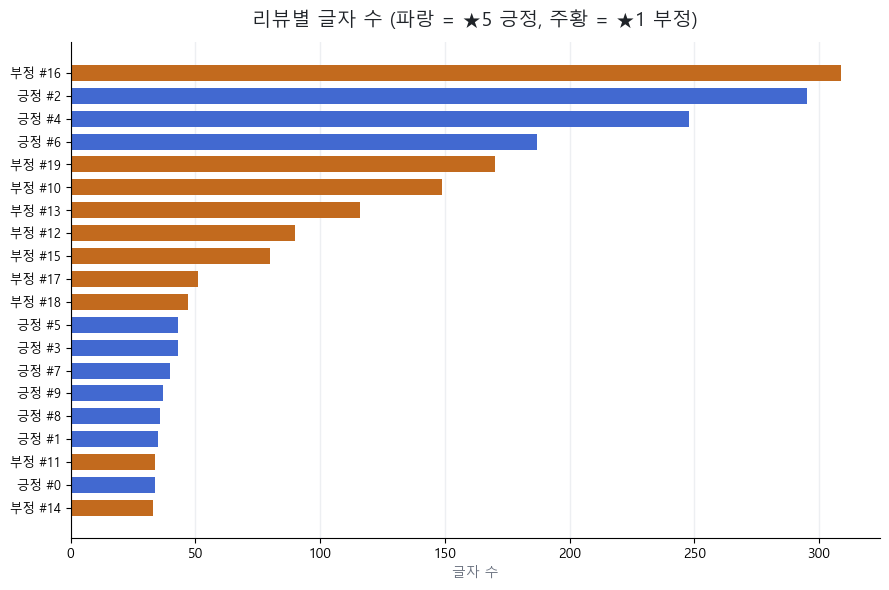

In [14]:
# 리뷰별 길이를 그대로 보여준다 (평균만 보면 분포가 겹치는지 알 수 없다)
order = np.argsort([len(r) for r in reviews])
colors = [BLUE if labels[i] == "긍정" else ORANGE for i in order]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(len(order)), [len(reviews[i]) for i in order],
               color=colors, height=0.7)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{labels[i]} #{i}" for i in order], fontsize=9)
ax.set_xlabel("글자 수", color=MUTED)
ax.set_title("리뷰별 글자 수 (파랑 = ★5 긍정, 주황 = ★1 부정)", fontsize=14, pad=12, color=INK)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="x", color="#EDEFF2", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 2.2 사전 기반 감성분석

In [15]:
# 화장품 리뷰 도메인에 맞춰 직접 만든 미니 감성 사전
POS_WORDS = set("""
좋다 좋아요 최고 만족 촉촉 순하다 강추 추천 빠르다 저렴 가성비 굿 놀라다
산뜻 편하다 부드럽다 재구매 깔끔 훌륭 예쁘다 시원 진정 무난 흡수
""".split())

NEG_WORDS = set("""
별로 실망 최악 아쉽다 트러블 자극 화끈 따갑다 건조 당기다 끈적 밀리다
깨지다 새다 거절 환불 반품 불편 속상 실패 방치 허술 뒤집어지다
피부염 여드름 묽다 느리다 부담 문제 불만
""".split())

# KnuSentiLex 감성 사전
try:
    import urllib.request
    base = "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/"
    pos = urllib.request.urlopen(base + "pos_pol_word.txt", timeout=10).read().decode("utf-8")
    neg = urllib.request.urlopen(base + "neg_pol_word.txt", timeout=10).read().decode("utf-8")
    # 파일은 "단어\t점수" 형식이고 줄 끝에 \r 이 붙어 있다. 첫 필드만 취한다.
    KNU_POS = {l.split("\t")[0].strip() for l in pos.split("\n")[19:]}
    KNU_NEG = {l.split("\t")[0].strip() for l in neg.split("\n")[19:]}
    KNU_POS = {w for w in KNU_POS if len(w) > 1}
    KNU_NEG = {w for w in KNU_NEG if len(w) > 1}
    print(f"KnuSentiLex 로드 성공 : 긍정 {len(KNU_POS)}개 / 부정 {len(KNU_NEG)}개")
except Exception as e:
    KNU_POS, KNU_NEG = set(), set()
    print("KnuSentiLex 다운로드 실패 -> 미니 사전만 사용합니다 :", type(e).__name__)

print(f"미니 사전 : 긍정 {len(POS_WORDS)}개 / 부정 {len(NEG_WORDS)}개")

KnuSentiLex 로드 성공 : 긍정 4857개 / 부정 9804개
미니 사전 : 긍정 24개 / 부정 30개


In [16]:
def dict_sentiment(text, pos_set=POS_WORDS, neg_set=NEG_WORDS):
    """사전에 있는 단어가 본문에 몇 개 들어 있는지 세어 비교한다"""
    p = sum(1 for w in pos_set if w in text)
    n = sum(1 for w in neg_set if w in text)
    if p == n:
        return "중립", p, n
    return ("긍정" if p > n else "부정"), p, n


res = [dict_sentiment(r) for r in reviews]
pred_dict = [r[0] for r in res]

df_dict = pd.DataFrame({"실제": labels, "예측": pred_dict,
                        "긍정어 수": [r[1] for r in res], "부정어 수": [r[2] for r in res],
                        "글자 수": [len(r) for r in reviews]})
acc_dict = np.mean(np.array(pred_dict) == np.array(labels))
print(f"사전 기반 정확도 : {acc_dict:.3f}")
print("예측 분포 :", Counter(pred_dict))
df_dict

사전 기반 정확도 : 0.550
예측 분포 : Counter({'긍정': 9, '중립': 8, '부정': 3})


,실제,예측,긍정어 수,부정어 수,글자 수
0,긍정,긍정,1,0,34
1,긍정,중립,0,0,35
2,긍정,긍정,4,2,295
3,긍정,긍정,1,0,43
4,긍정,긍정,4,3,248
5,긍정,긍정,1,0,43
6,긍정,긍정,4,1,187
7,긍정,긍정,3,0,40
8,긍정,중립,0,0,36
9,긍정,긍정,1,0,37


In [17]:
# 범용 사전(KnuSentiLex) 과 도메인 미니 사전 비교
if KNU_POS:
    res_knu = [dict_sentiment(r, KNU_POS, KNU_NEG) for r in reviews]
    pred_knu = [r[0] for r in res_knu]
    acc_knu = np.mean(np.array(pred_knu) == np.array(labels))

    cmp_rows = []
    for name, rr, pp in [("도메인 미니 사전 (54단어)", res, pred_dict),
                         (f"KnuSentiLex (범용, {len(KNU_POS) + len(KNU_NEG):,}단어)", res_knu, pred_knu)]:
        ok = np.array(pp) == np.array(labels)
        cmp_rows.append({
            "사전": name,
            "정확도": round(ok.mean(), 3),
            "중립 판정 수": sum(1 for x in pp if x == "중립"),
            "긍정리뷰 평균 매칭(긍정어/부정어)": f"{np.mean([x[1] for x in rr[:10]]):.1f} / {np.mean([x[2] for x in rr[:10]]):.1f}",
            "부정리뷰 평균 매칭(긍정어/부정어)": f"{np.mean([x[1] for x in rr[10:]]):.1f} / {np.mean([x[2] for x in rr[10:]]):.1f}",
        })
    display(pd.DataFrame(cmp_rows))
else:
    print("KnuSentiLex 를 불러오지 못해 비교를 건너뜁니다.")

,사전,정확도,중립 판정 수,긍정리뷰 평균 매칭(긍정어/부정어),부정리뷰 평균 매칭(긍정어/부정어)
0,도메인 미니 사전 (54단어),0.55,8,1.9 / 0.6,0.4 / 0.7
1,"KnuSentiLex (범용, 14,661단어)",0.65,3,2.8 / 0.5,0.9 / 0.9


> **이번 데이터에서는 범용 사전(KnuSentiLex, 1.5만 단어)이 도메인 미니 사전(54단어)보다 좋았다(0.65 vs 0.55).**  
> 미니 사전은 `중립` 판정이 8건이나 나왔는데, 사전이 작아 **매칭되는 단어 자체가 없었기** 때문이다.
>
> 다만 두 사전 모두 **부정 리뷰를 잘 못 잡는다.** 매칭 통계를 보면,
>
> | 사전 | 긍정리뷰 매칭(긍정어/부정어) | 부정리뷰 매칭(긍정어/부정어) |
> |---|---|---|
> | 도메인 미니 사전 | 1.9 / 0.6 | 0.4 / **0.7** |
> | KnuSentiLex | 2.8 / 0.5 | 0.9 / **0.9** |
>
> 부정 리뷰에서는 긍정어와 부정어가 **거의 같은 수로 잡힌다.**  
> `제품은 좋은데 휴대용 케이스는 의미가 없네요`, `성분 자체는 좋아요! 좋은데 패드 이대로면...`  
> 처럼 **칭찬과 불만이 한 문장에 섞여 있기 때문**이다.  
> 사전 방식은 단어를 셀 뿐 **문맥과 `~는데`, `~지만`와 같은 표현을 고려하지 못한다.**

## 2.3 Naive Bayes 기반 감성분석 — OOV 처리방식 비교

1.2에서 만든 분류기를 그대로 쓴다. 데이터가 20개뿐이므로 LOOCV 로 평가한다.  
`ignore_oov` 옵션만 바꿔 두 번 돌려 본다.

In [18]:
def loocv_nb(docs, labels, k=0.5, ignore_oov=True):
    preds = []
    for tr, te in LeaveOneOut().split(docs):
        m = NaiveBayesClassifier(k=k, ignore_oov=ignore_oov).fit(
            [docs[i] for i in tr], [labels[i] for i in tr])
        preds.append(m.predict(docs[te[0]]))
    return np.array(preds)


rows = []
for ig in [False, True]:
    p = loocv_nb(rev_tokens, labels, ignore_oov=ig)
    ok = p == np.array(labels)
    rows.append({
        "OOV 처리": "<UNK> 확률 부여" if not ig else "무시(sklearn 방식)",
        "전체 정확도": round(ok.mean(), 3),
        "긍정 정확도": round(ok[:10].mean(), 2),
        "부정 정확도": round(ok[10:].mean(), 2),
    })

pd.DataFrame(rows)

,OOV 처리,전체 정확도,긍정 정확도,부정 정확도
0,<UNK> 확률 부여,0.70,0.9,0.5
1,무시(sklearn 방식),0.65,0.9,0.4


In [19]:
# 문서별 토큰 수와 OOV(학습에 없던 단어) 수를 직접 확인한다
detail = []
for tr, te in LeaveOneOut().split(rev_tokens):
    m = NaiveBayesClassifier(k=0.5, ignore_oov=False).fit(
        [rev_tokens[i] for i in tr], [labels[i] for i in tr])
    i = te[0]
    s = m.predict_log(rev_tokens[i])
    detail.append({
        "실제": labels[i], "예측(<UNK>방식)": m.predict(rev_tokens[i]),
        "토큰 수": len(rev_tokens[i]),
        "OOV 수": sum(1 for t in rev_tokens[i] if t not in m.vocab_),
        "log P(긍정)": round(s["긍정"], 1), "log P(부정)": round(s["부정"], 1),
    })
pd.DataFrame(detail)

,실제,예측(<UNK>방식),토큰 수,OOV 수,log P(긍정),log P(부정)
0,긍정,긍정,8,3,-41.1,-42.7
1,긍정,부정,6,2,-31.4,-30.8
2,긍정,긍정,52,27,-278.4,-296.9
3,긍정,긍정,10,4,-55.4,-56.2
4,긍정,긍정,45,20,-242.8,-255.7
5,긍정,긍정,9,6,-52.4,-54.2
6,긍정,긍정,36,18,-202.3,-205.2
7,긍정,긍정,7,0,-37.9,-40.4
8,긍정,긍정,5,3,-27.3,-28.8
9,긍정,긍정,5,1,-22.5,-24.5


> **OOV 처리 방식을 바꿔도 결과가 크게 달라지지 않았다(0.700 vs 0.650).**  
> 두 클래스의 토큰 수가 18.3개 / 18.7개로 비슷해서 `<UNK>` 페널티가 양쪽에 **공평하게** 걸렸기 때문이다.  
>
> 대신 눈에 띄는 것은 **긍정은 잘 맞히는데(0.9) 부정은 못 맞힌다(0.4~0.5)** 는 비대칭이다.  
> 이건 길이 때문이 아니라 **내용** 때문이다.  
> ★1 리뷰의 상당수가 `배송`, `환불`, `사은품`, `옵션 설정` 처럼 **제품이 아니라 판매 과정에 대한 불만**이라  
> 어휘가 제각각이고 서로 겹치지 않는다. 반면 ★5 리뷰는 `좋다`, `촉촉`, `재구매`, `양 많다` 로 어휘가 수렴한다.

## 2.4 길이 baseline — "길이 하나만" 가지고 분류해 보기

내용은 전혀 보지 않고 **글자 수 하나만** 특징으로 써서 분류해 본다.  
이 baseline 이 높게 나오면 **길이가 정답을 알려주는 누출(leakage) 변수**라는 뜻이고,  
낮게 나오면 길이에는 정보가 없다는 뜻이다. **모든 텍스트 분류에서 먼저 확인해보면 좋다.**

In [20]:
X_len = np.array([[len(r)] for r in reviews])
y_arr = np.array(labels)

pred_len = []
for tr, te in LeaveOneOut().split(X_len):
    lr = LogisticRegression().fit(X_len[tr], y_arr[tr])
    pred_len.append(lr.predict(X_len[te])[0])

acc_loo = np.mean(np.array(pred_len) == y_arr)
acc_self = LogisticRegression().fit(X_len, y_arr).score(X_len, y_arr)

print(f"글자 수 하나만으로 LOOCV 정확도        : {acc_loo:.3f}")
print(f"글자 수 하나만으로 전체학습 후 자기평가 : {acc_self:.3f}   <- 무작위(0.5)와 거의 같다")
print("예측 분포 :", pd.Series(pred_len).value_counts().to_dict())

글자 수 하나만으로 LOOCV 정확도        : 0.000
글자 수 하나만으로 전체학습 후 자기평가 : 0.550   <- 무작위(0.5)와 거의 같다
예측 분포 : {np.str_('부정'): 10, np.str_('긍정'): 10}


---
## 텍스트의 길이가 분석 결과에 미치는 영향

### 1) 수집한 텍스트의 길이 확인

| 라벨 | 평균 글자 수 | 최소 | 최대 | 평균 토큰 수 |
|---|---|---|---|---|
| ★5 (긍정) | **99.8자** | 34 | 295 | 18.3 |
| ★1 (부정) | **107.9자** | 33 | 309 | 18.7 |

**부정이 긍정보다 1.08배 길 뿐, 두 분포는 거의 완전히 겹쳤다.**  
가장 긴 두 리뷰(309자·295자)와 가장 짧은 두 리뷰(34자·33자)가 각각 서로 다른 클래스다.

- ★5 쪽에 **리뷰 이벤트를 노린 장문 리뷰**(295자, 248자, 187자)가 섞여 있었다.
- ★1 쪽에 `제품은 좋은데 휴대용 케이스는 의미가 없네요 질질 새서 ...` 처럼  
  **한 줄로 끝나는 짧은 불만**이 여럿 있었다.

### 2) 길이가 균형 잡혔을 때 — 이번 데이터에서 확인한 것

**① 길이 baseline 이 무작위 수준이다 → 길이는 영향을 미치지 않는다.**

글자 수 하나만으로 분류했을 때 전체학습 자기평가가 **0.55** 로, 무작위(0.5)와 사실상 같았다.

**② OOV 처리 방식을 바꿔도 결과가 거의 안 바뀐다**

| 방식 | 전체 | 긍정 | 부정 |
|---|---|---|---|
| `<UNK>` 확률 부여 | 0.700 | 0.90 | 0.50 |
| OOV 무시 | 0.650 | 0.90 | 0.40 |

두 클래스의 평균 토큰 수(18.3 / 18.7)와 OOV 비율(40.4% / 43.9%)이 비슷해서
`<UNK>` 페널티가 **양쪽에 공평하게** 걸렸기 때문이다.

**③ 그래도 부정 정확도가 낮다 — 이건 길이가 아니라 내용의 문제**

★1 리뷰의 상당수가 `배송`, `환불`, `사은품`, `옵션 설정` 처럼 **제품이 아니라 판매 과정에 대한 불만**이라  
어휘가 제각각이고 서로 겹치지 않는다. 반면 ★5 리뷰는 `좋다`, `촉촉`, `재구매`, `양 많다` 로 어휘가 수렴한다.  
게다가 `제품은 좋은데 ...`, `성분 자체는 좋아요! 좋은데 ...` 처럼  
**칭찬과 불만이 한 문장에 섞여** 사전 방식과 BoW 방식 모두를 헷갈리게 만든다.

> 길이가 균형 잡혀 있으면 **성능이 낮을 때 그 원인을 내용에서 찾을 수 있**고,  
> 이것이 길이를 통제하는 것이 텍스트 처리에서 중요한 이유다.